Loading data...
Dataset Shape: (129146, 19)
Shape after dropping columns: (129146, 13)
Shape after encoding: (129146, 196)
X Shape: (129146, 195)
y Shape: (129146,)
Training Random Forest...
Model trained successfully

Top 10 Important Features
                     Feature  Importance
3    time_since_signup_hours    0.371696
7   device_transaction_count    0.235544
2                 ip_address    0.082090
0             purchase_value    0.066594
1                        age    0.060662
4                hour_of_day    0.053813
5                day_of_week    0.031425
14                     sex_M    0.010411
9                 source_SEO    0.007078
11                browser_IE    0.006781


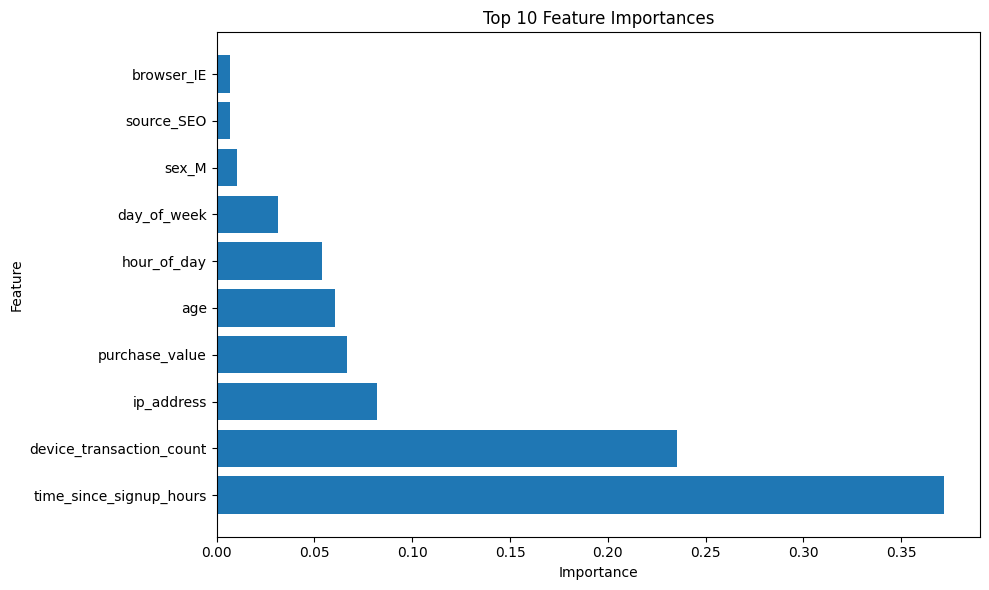


Feature importance saved

EXPLAINABILITY SUMMARY
1. time_since_signup_hours (0.3717)
2. device_transaction_count (0.2355)
3. ip_address (0.0821)
4. purchase_value (0.0666)
5. age (0.0607)
6. hour_of_day (0.0538)
7. day_of_week (0.0314)
8. sex_M (0.0104)
9. source_SEO (0.0071)
10. browser_IE (0.0068)

Explainability completed successfully


In [ ]:
# ==========================================
# SHAP / EXPLAINABILITY NOTEBOOK
# (FAST VERSION - NO SHAP)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# -----------------------------------
# Load Processed Data
# -----------------------------------

print("Loading data...")

df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

print("Dataset Shape:", df.shape)

# -----------------------------------
# Drop Unnecessary Columns
# -----------------------------------

drop_cols = [
    "signup_time",
    "purchase_time",
    "user_id",
    "device_id",
    "lower_bound_ip_address",
    "upper_bound_ip_address"
]

existing_cols = [
    col for col in drop_cols
    if col in df.columns
]

df.drop(
    columns=existing_cols,
    inplace=True
)

print("Shape after dropping columns:", df.shape)

# -----------------------------------
# One-Hot Encode Categorical Features
# -----------------------------------

categorical_cols = [
    "source",
    "browser",
    "sex",
    "country"
]

existing_cats = [
    col for col in categorical_cols
    if col in df.columns
]

df = pd.get_dummies(
    df,
    columns=existing_cats,
    drop_first=True
)

print("Shape after encoding:", df.shape)

# -----------------------------------
# Features and Target
# -----------------------------------

X = df.drop("class", axis=1)
y = df["class"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# -----------------------------------
# Train/Test Split
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------------
# Train Random Forest
# -----------------------------------

print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

print("Model trained successfully")

# -----------------------------------
# Feature Importance
# -----------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")
print("=" * 50)
print(importance.head(10))

# -----------------------------------
# Plot Top 10 Features
# -----------------------------------

top10 = importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

# Save image
plt.savefig(
    "../reports/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

# -----------------------------------
# Save Feature Importance Table
# -----------------------------------

importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("\nFeature importance saved")

# -----------------------------------
# Project Summary
# -----------------------------------

print("\n" + "=" * 60)
print("EXPLAINABILITY SUMMARY")
print("=" * 60)

for i, row in enumerate(
    importance.head(10).itertuples(),
    start=1
):
    print(
        f"{i}. {row.Feature} "
        f"({row.Importance:.4f})"
    )

print("\nExplainability completed successfully")
